In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotly import express as px

In [15]:
# Load the datasets
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv", on_bad_lines='skip')

In [17]:
matches.head(5)

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [18]:
deliveries.head(5)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [19]:
# Basic Info about the datasets
print(f"Matches Dataset Info:")
print(matches.info())

Matches Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   Season           756 non-null    object
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3      

In [20]:
print(f"Deliveries Dataset Info:")
print(deliveries.info())

Deliveries Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179078 entries, 0 to 179077
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          179078 non-null  int64 
 1   inning            179078 non-null  int64 
 2   batting_team      179078 non-null  object
 3   bowling_team      179078 non-null  object
 4   over              179078 non-null  int64 
 5   ball              179078 non-null  int64 
 6   batsman           179078 non-null  object
 7   non_striker       179078 non-null  object
 8   bowler            179078 non-null  object
 9   is_super_over     179078 non-null  int64 
 10  wide_runs         179078 non-null  int64 
 11  bye_runs          179078 non-null  int64 
 12  legbye_runs       179078 non-null  int64 
 13  noball_runs       179078 non-null  int64 
 14  penalty_runs      179078 non-null  int64 
 15  batsman_runs      179078 non-null  int64 
 16  extra_runs   

In [21]:
# Check for missing values
print("\nMissing Values in Matches Dataset:")
print(matches.isnull().sum())

print("\nMissing Values in Deliveries Dataset:")
print(deliveries.isnull().sum())


Missing Values in Matches Dataset:
id                   0
Season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

Missing Values in Deliveries Dataset:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismi

In [41]:

print(f"Shape of matches dataset: {matches.shape}")
print(f"Shape of deliveries dataset: {deliveries.shape}")


Shape of matches dataset: (655, 17)
Shape of deliveries dataset: (158117, 18)


In [36]:
# Drop specified columns from deliveries DataFrame
deliveries = deliveries.drop(['player_dismissed', 'dismissal_kind', 'fielder'], axis=1)

# Drop 'umpire3' column from matches DataFrame
matches = matches.drop('umpire3', axis=1)

# Drop rows with any missing values in the matches DataFrame
matches = matches.dropna()


In [22]:
# Basic stats for numeric columns in matches
print("\nBasic Stats for Matches Dataset:")
print(matches.describe())


Basic Stats for Matches Dataset:
                 id  dl_applied  win_by_runs  win_by_wickets
count    756.000000  756.000000   756.000000      756.000000
mean    1792.178571    0.025132    13.283069        3.350529
std     3464.478148    0.156630    23.471144        3.387963
min        1.000000    0.000000     0.000000        0.000000
25%      189.750000    0.000000     0.000000        0.000000
50%      378.500000    0.000000     0.000000        4.000000
75%      567.250000    0.000000    19.000000        6.000000
max    11415.000000    1.000000   146.000000       10.000000


In [23]:
# Basic stats for numeric columns in deliveries
print("\nBasic Stats for Deliveries Dataset:")
print(deliveries.describe())


Basic Stats for Deliveries Dataset:
            match_id         inning           over           ball  \
count  179078.000000  179078.000000  179078.000000  179078.000000   
mean     1802.252957       1.482952      10.162488       3.615587   
std      3472.322805       0.502074       5.677684       1.806966   
min         1.000000       1.000000       1.000000       1.000000   
25%       190.000000       1.000000       5.000000       2.000000   
50%       379.000000       1.000000      10.000000       4.000000   
75%       567.000000       2.000000      15.000000       5.000000   
max     11415.000000       5.000000      20.000000       9.000000   

       is_super_over      wide_runs       bye_runs    legbye_runs  \
count  179078.000000  179078.000000  179078.000000  179078.000000   
mean        0.000452       0.036721       0.004936       0.021136   
std         0.021263       0.251161       0.116480       0.194908   
min         0.000000       0.000000       0.000000       0.000000

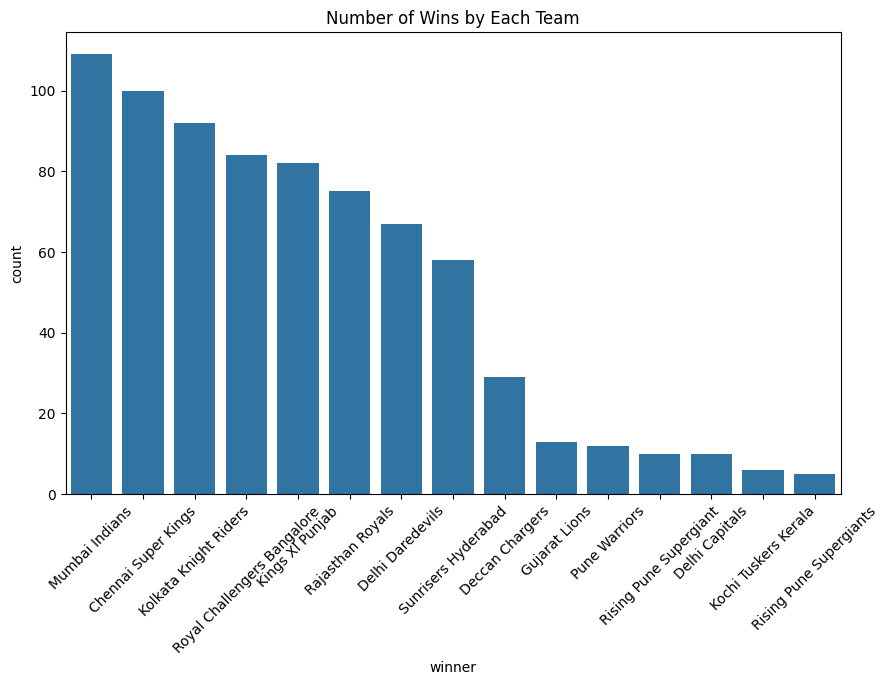

In [24]:
# Distribution of match results by teams
plt.figure(figsize=(10,6))
sns.countplot(data=matches, x='winner', order=matches['winner'].value_counts().index)
plt.title("Number of Wins by Each Team")
plt.xticks(rotation=45)
plt.show()

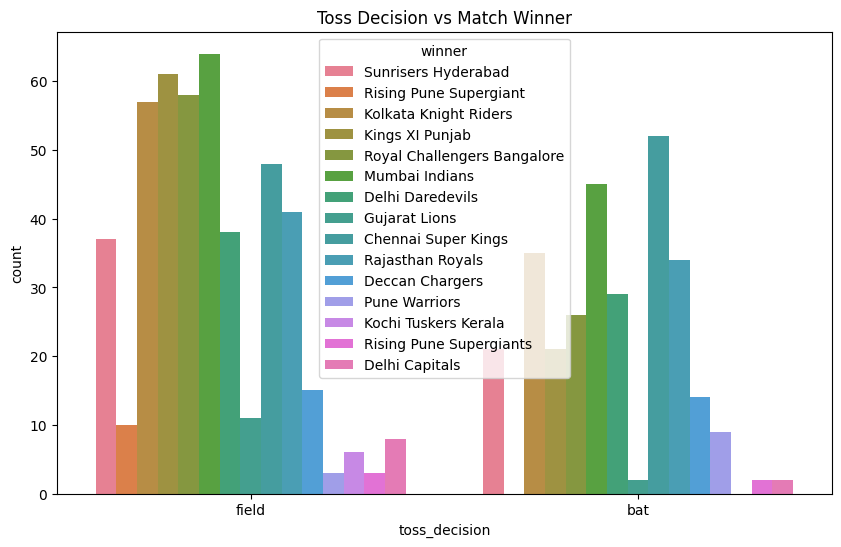

In [25]:
# Toss Decision vs Match Winner
plt.figure(figsize=(10,6))
sns.countplot(data=matches, x='toss_decision', hue='winner')
plt.title("Toss Decision vs Match Winner")
plt.show()

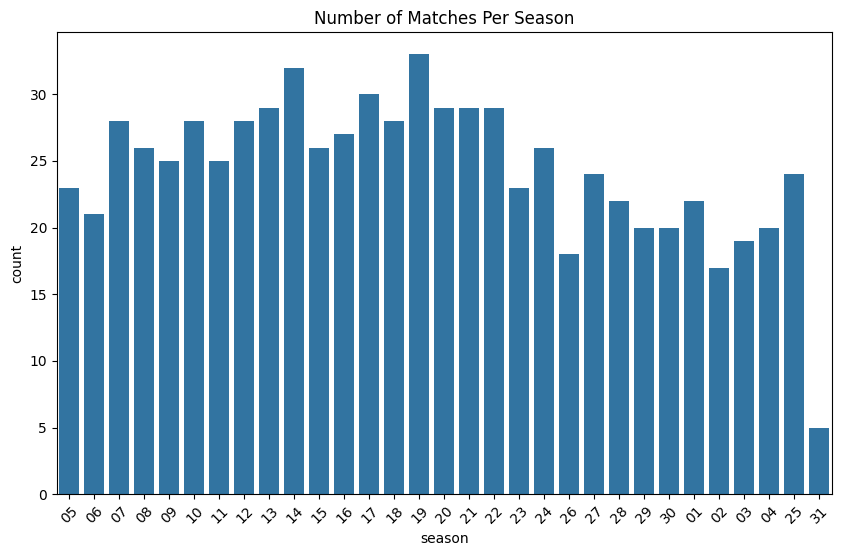

In [26]:
# Season-wise number of matches
matches['season'] = matches['date'].apply(lambda x: x.split("-")[0])
plt.figure(figsize=(10,6))
sns.countplot(data=matches, x='season')
plt.title("Number of Matches Per Season")
plt.xticks(rotation=45)
plt.show()

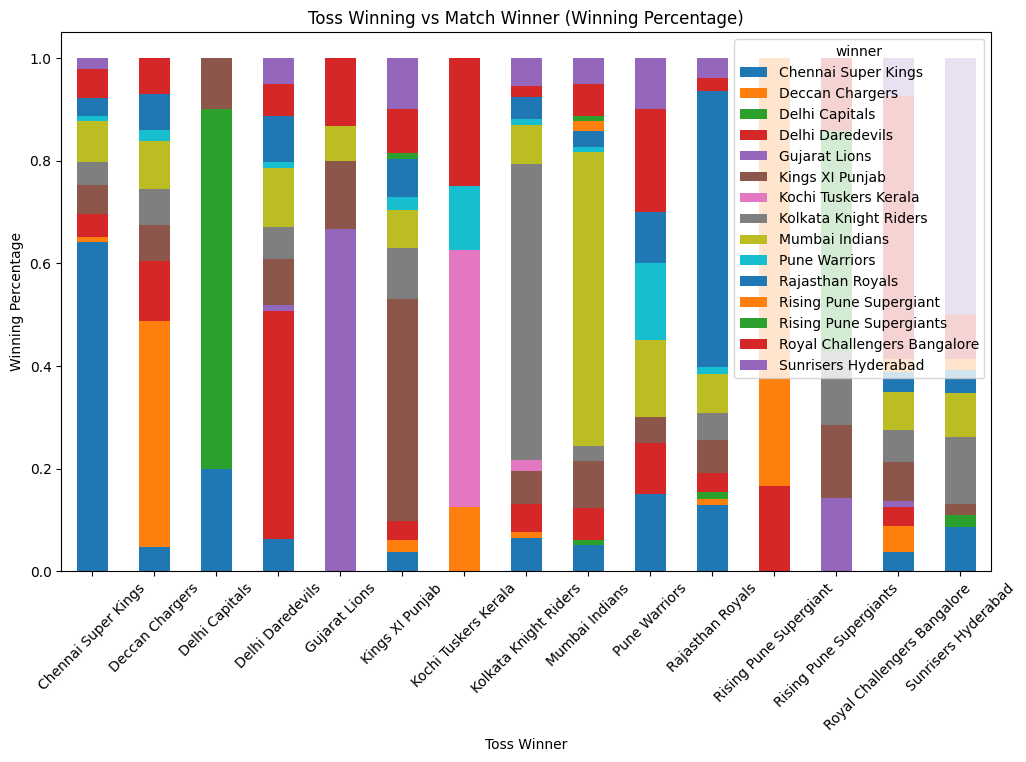

In [27]:
# Toss Winning vs Match Winner
toss_win = matches.groupby('toss_winner')['winner'].value_counts().unstack().fillna(0)
toss_win = toss_win.apply(lambda x: x / x.sum(), axis=1)  # Calculate the ratio of winning
toss_win.plot(kind='bar', figsize=(12, 7), stacked=True)
plt.title("Toss Winning vs Match Winner (Winning Percentage)")
plt.ylabel('Winning Percentage')
plt.xlabel('Toss Winner')
plt.xticks(rotation=45)
plt.show()

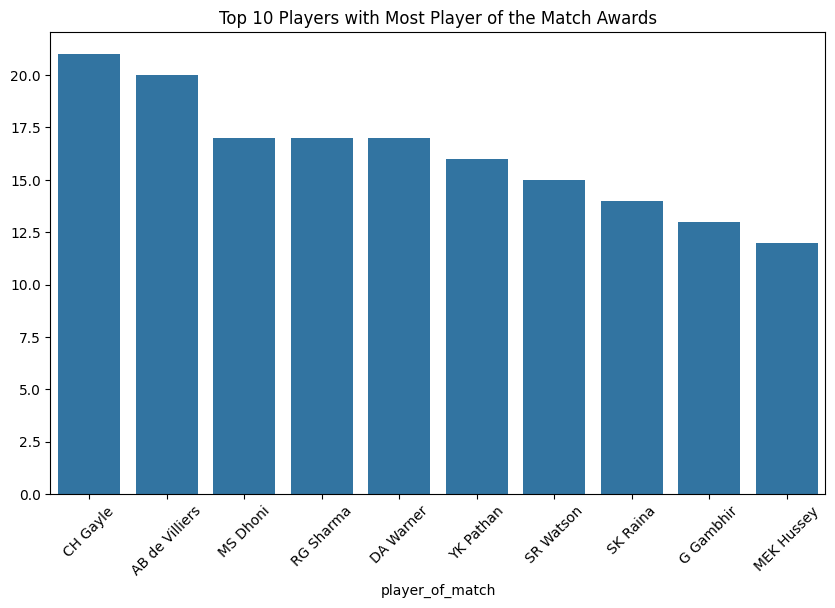

In [28]:
# Top 10 Players with Most Player of the Match Awards
top_players = matches['player_of_match'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_players.index, y=top_players.values)
plt.title("Top 10 Players with Most Player of the Match Awards")
plt.xticks(rotation=45)
plt.show()

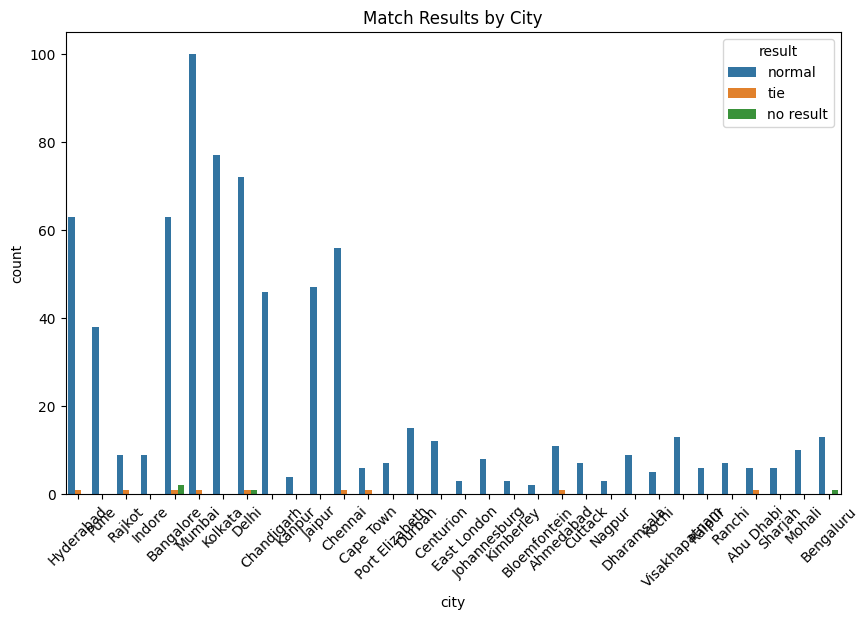

In [29]:
# Match Results by City
plt.figure(figsize=(10,6))
sns.countplot(data=matches, x='city', hue='result')
plt.title("Match Results by City")
plt.xticks(rotation=45)
plt.show()

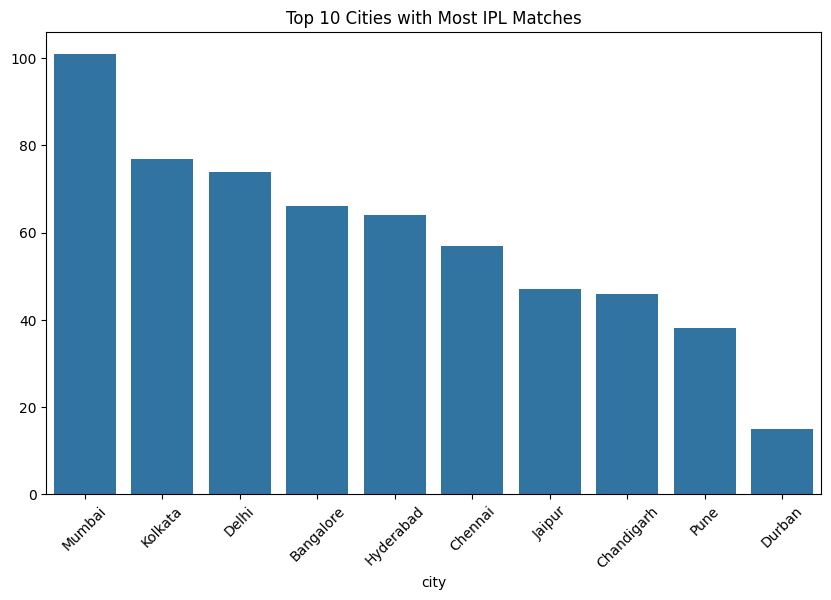

In [30]:
# Top 10 Cities with the Most Matches
top_cities = matches['city'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_cities.index, y=top_cities.values)
plt.title("Top 10 Cities with Most IPL Matches")
plt.xticks(rotation=45)
plt.show()

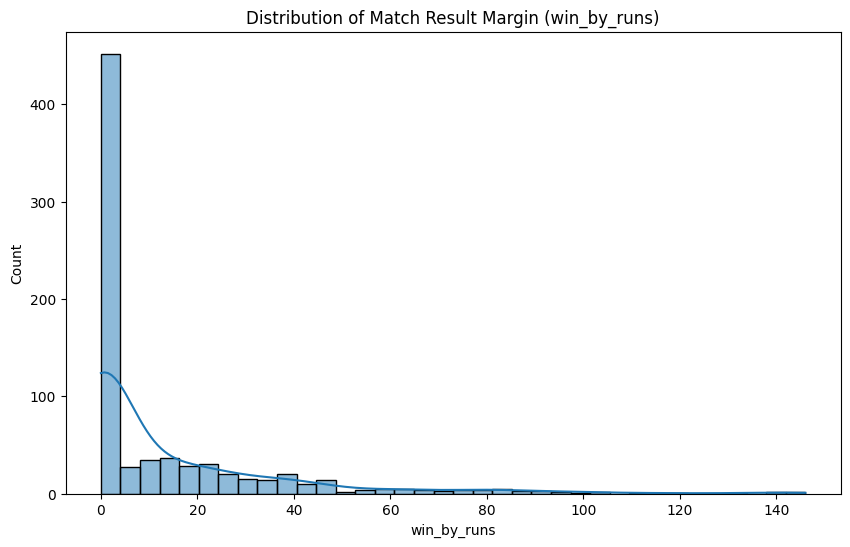

In [8]:
# Distribution of Runs Scored (Result Margin)
plt.figure(figsize=(10,6))
# Check if 'result_margin' exists, if not, use 'win_by_runs'
if 'result_margin' in matches.columns:
    sns.histplot(matches['result_margin'].dropna(), kde=True)
else:
    sns.histplot(matches['win_by_runs'].dropna(), kde=True) # Use 'win_by_runs' if 'result_margin' not found
    plt.title("Distribution of Match Result Margin (win_by_runs)") # Update title to reflect the column used
plt.show()

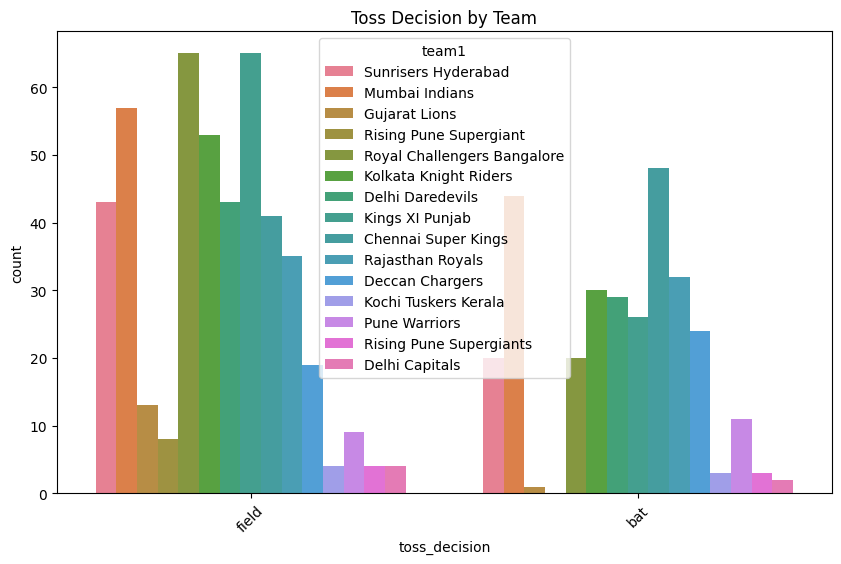

In [6]:
# Toss Decision by Team
plt.figure(figsize=(10,6))
sns.countplot(data=matches, x='toss_decision', hue='team1') # Changed hue to 'team1'
plt.title("Toss Decision by Team")
plt.xticks(rotation=45)
plt.show()

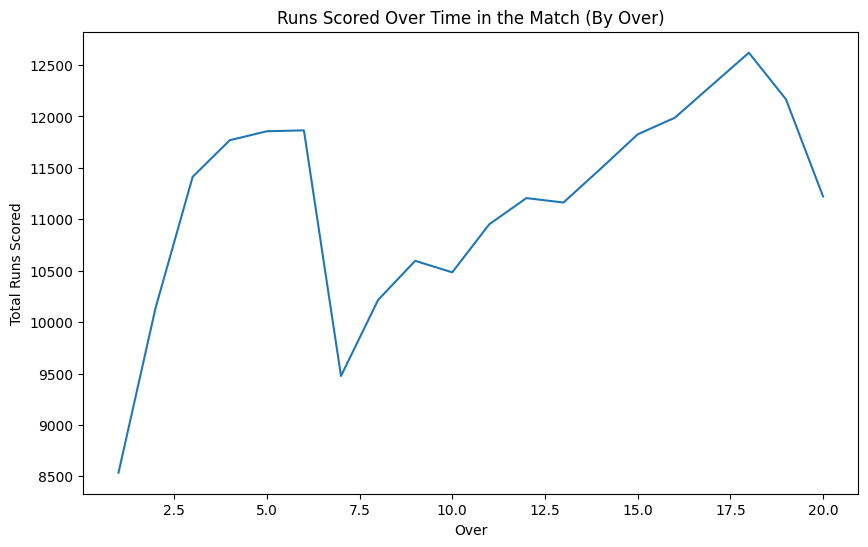

In [9]:
# Delivery Analysis: Runs Scored Over Time
deliveries['over'] = deliveries['over'].astype(int)
runs_by_over = deliveries.groupby('over')['batsman_runs'].sum()

plt.figure(figsize=(10,6))
runs_by_over.plot(kind='line')
plt.title("Runs Scored Over Time in the Match (By Over)")
plt.xlabel('Over')
plt.ylabel('Total Runs Scored')
plt.show()



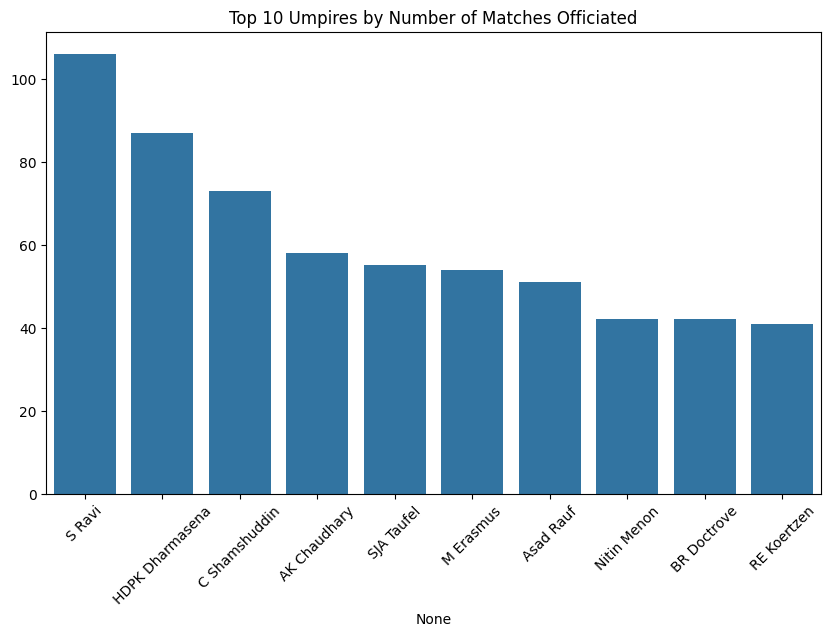

In [31]:
top_umpires = matches[['umpire1', 'umpire2']].stack().value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_umpires.index, y=top_umpires.values)
plt.title("Top 10 Umpires by Number of Matches Officiated")
plt.xticks(rotation=45)
plt.show()


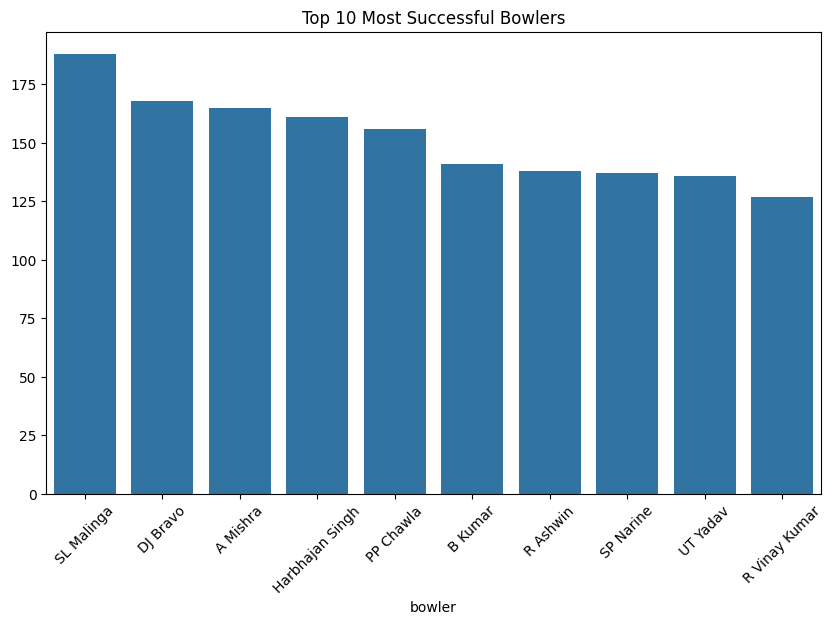

In [32]:
top_bowlers = deliveries.groupby('bowler')['player_dismissed'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_bowlers.index, y=top_bowlers.values)
plt.title("Top 10 Most Successful Bowlers")
plt.xticks(rotation=45)
plt.show()

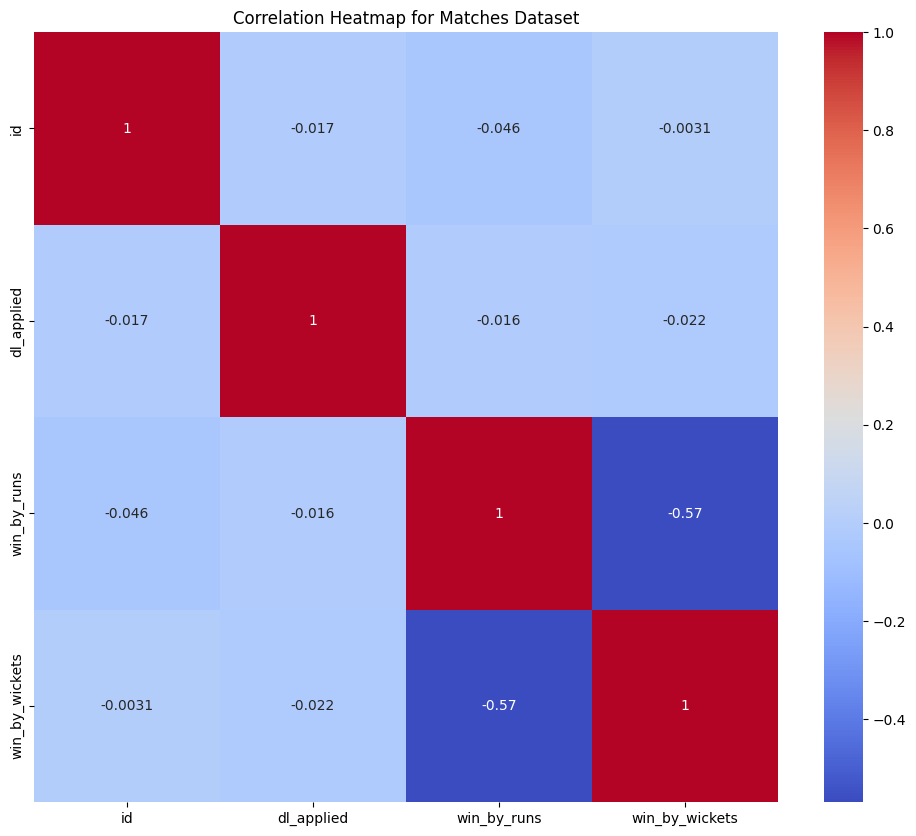

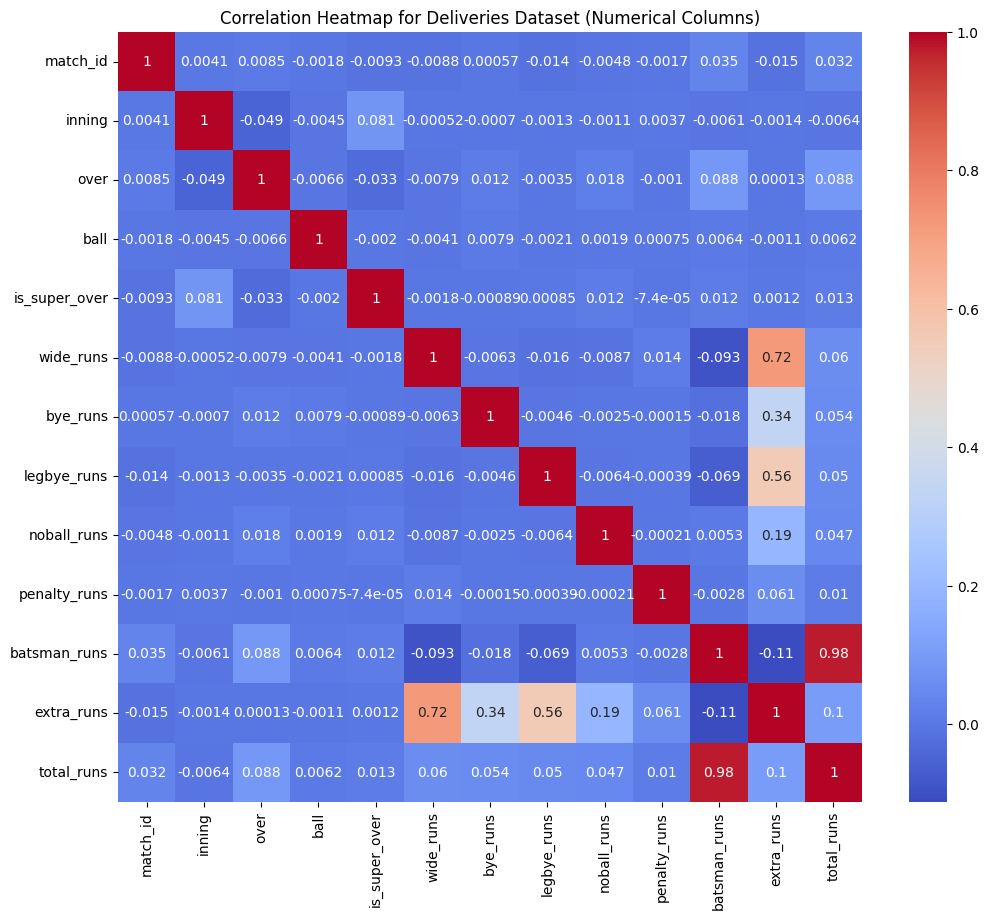

In [43]:
numerical_cols_matches = matches.select_dtypes(include=np.number).columns # Fixed typo: 'umerical_cols_matches' to 'numerical_cols_matches'

plt.figure(figsize=(12, 10))
sns.heatmap(matches[numerical_cols_matches].corr(), annot=True, cmap='coolwarm') # Use only numerical columns
plt.title('Correlation Heatmap for Matches Dataset')
plt.show()

# Select numerical columns for correlation analysis in deliveries dataset
numerical_cols_deliveries = deliveries.select_dtypes(include=np.number).columns
# Correlation Heatmap for Deliveries Dataset (numerical columns only)
plt.figure(figsize=(12, 10))
sns.heatmap(deliveries[numerical_cols_deliveries].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap for Deliveries Dataset (Numerical Columns)')
plt.show()